In [ ]:
import pickle
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm
import networkx as nx

import os 
from atomica.data import filter_for_segment
from atomica.data.dataset import PDBDataset
from atomica.models.classifier_model import MultiClassClassifierModel
from atomica.trainers.abs_trainer import Trainer

AF3_ligands = ["ADP", "ATP", "GTP", "GDP", "FAD", "NAD", "NAP", "NDP", "HEM", "HEC", "PLM", "OLA", "MYR", "CIT", "CLA", "CHL", "BCL", "BCB"]
AF3_metal_ions = ['MG', 'ZN', 'CA', 'MN', 'FE', 'NA', 'CO', 'CU', 'K']

In [ ]:

def get_interface_dataset(dataset, ligand_type):
    if ligand_type == 'cofactor':
        ligands = AF3_ligands
    elif ligand_type == 'metal_ion':
        ligands = AF3_metal_ions
    else:
        raise ValueError('ligand_type should be either cofactor or metal_ion')
    interface_dataset = []
    for item in dataset:
        ligand = item['id'].split("_")[-2]
        if ligand not in ligands:
            continue
        new_item = {
            'id': item['id'],
            'data': filter_for_segment(item['data'], 0),
            'label': ligands.index(ligand)
        }
        interface_dataset.append(new_item)
    return interface_dataset

def get_binary_interface_dataset(dataset, chosen_ligand):
    interface_dataset = []
    for item in dataset:
        ligand = item['id'].split("_")[-2]
        new_item = {
            'id': item['id'],
            'data': filter_for_segment(item['data'], 0),
            'label': int(ligand == chosen_ligand)
        }
        interface_dataset.append(new_item)
    return interface_dataset

print("num ligands: ", len(AF3_ligands))
print("num metal ions: ", len(AF3_metal_ions))

num ligands:  18
num metal ions:  9


In [6]:
with open("/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/raw_QBioLiP_06_2024/Pion/nonredund.fasta", "r") as f:
    lines = f.readlines()
    pion_fastas = {k.strip().replace(">", ""):v.strip().replace(">", "") for k,v in zip(lines[::2], lines[1::2])}

def get_pion_fastas(dataset, chosen_ion):
    chosen_ion_fastas = {}
    other_fastas = {}
    for item in dataset:
        ion = item['id'].split("_")[-2]
        pdb_file = item['id'].split(".pdb")[0]
        chains = set(pdb_index.split('_')[0] for pdb_index in item['block_to_pdb_indexes'].values())
        if chosen_ion == ion:
            for chain in chains:
                chosen_ion_fastas[f"{item['id']}_{chain}"] = pion_fastas[f"{pdb_file}_{chain}"]
        else:
            for chain in chains:
                other_fastas[f"{item['id']}_{chain}"] = pion_fastas[f"{pdb_file}_{chain}"]
    return chosen_ion_fastas, other_fastas

with open("/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/raw_QBioLiP_06_2024/PL/nonredund.fasta", "r") as f:
    lines = f.readlines()
    pl_fastas = {k.strip().replace(">", ""):v.strip().replace(">", "") for k,v in zip(lines[::2], lines[1::2])}

def get_pl_fastas(dataset, chosen_ligand):
    chosen_ligand_fastas = {}
    other_fastas = {}
    for item in dataset:
        ligand = item['id'].split("_")[-2]
        pdb_file = item['id'].split(".pdb")[0]
        chains = set(pdb_index.split('_')[0] for pdb_index in item['block_to_pdb_indexes'].values())
        if chosen_ligand == ligand:
            for chain in chains:
                chosen_ligand_fastas[f"{item['id']}_{chain}"] = pl_fastas[f"{pdb_file}_{chain}"]
        else:
            for chain in chains:
                other_fastas[f"{item['id']}_{chain}"] = pl_fastas[f"{pdb_file}_{chain}"]
    return chosen_ligand_fastas, other_fastas

# Pion
Issues the dataset is quite imbalanced

In [27]:
test_path = "/n/holystore01/LABS/mzitnik_lab/Lab/afang/QBioLiP/sequence_30_split/Pion_test.pkl"
train_path = "/n/holystore01/LABS/mzitnik_lab/Lab/afang/QBioLiP/sequence_30_split/Pion_train.pkl"
valid_path = "/n/holystore01/LABS/mzitnik_lab/Lab/afang/QBioLiP/sequence_30_split/Pion_valid.pkl"

with open(test_path, 'rb') as f:
    test = pickle.load(f)

with open(train_path, 'rb') as f:
    train = pickle.load(f)

with open(valid_path, 'rb') as f:
    valid = pickle.load(f)

In [6]:
test_ligands = Counter([x['id'].split("_")[-2] for x in test])
train_ligands = Counter([x['id'].split("_")[-2] for x in train])
valid_ligands = Counter([x['id'].split("_")[-2] for x in valid])

<Axes: xlabel='ligand', ylabel='proportion'>

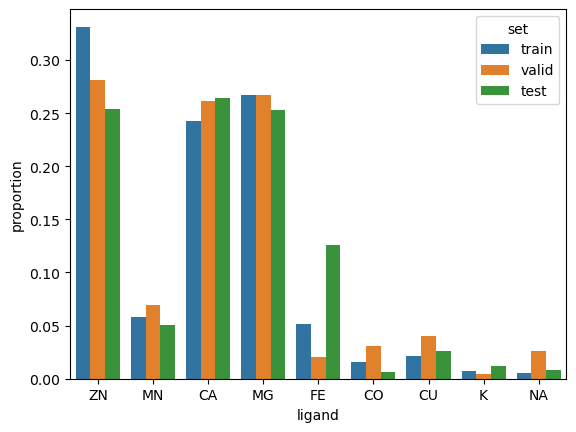

In [7]:
ligands_df = pd.DataFrame([], columns=['ligand', 'count', 'set'])
for split, ligands in {'train': train_ligands, 'valid': valid_ligands, 'test': test_ligands}.items():
    ligands = {k: v for k, v in ligands.items() if k in AF3_metal_ions}
    df = pd.DataFrame.from_dict(ligands, orient='index').reset_index()
    df.columns = ['ligand', 'count']
    df['set'] = split
    df['proportion'] = df['count'] / df['count'].sum()
    ligands_df = pd.concat([ligands_df, df])

sns.barplot(x='ligand', y='proportion', hue='set', data=ligands_df)

In [16]:
test_interface = get_interface_dataset(test, 'metal_ion')
train_interface = get_interface_dataset(train, 'metal_ion')
valid_interface = get_interface_dataset(valid, 'metal_ion')

output_dir = "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/protein_interface/Pion"
with open(f"{output_dir}/Pion_sequence_30_test.pkl", 'wb') as f:
    pickle.dump(test_interface, f)
with open(f"{output_dir}/Pion_sequence_30_train.pkl", 'wb') as f:
    pickle.dump(train_interface, f)
with open(f"{output_dir}/Pion_sequence_30_valid.pkl", 'wb') as f:
    pickle.dump(valid_interface, f)

In [20]:
output_dir = "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/protein_interface/Pion"
for ion in AF3_metal_ions:
    test_binary = get_binary_interface_dataset(test, ion)
    train_binary = get_binary_interface_dataset(train, ion)
    valid_binary = get_binary_interface_dataset(valid, ion)

    with open(f"{output_dir}/Pion_sequence_30_{ion}_test.pkl", 'wb') as f:
        pickle.dump(test_binary, f)
    with open(f"{output_dir}/Pion_sequence_30_{ion}_train.pkl", 'wb') as f:
        pickle.dump(train_binary, f)
    with open(f"{output_dir}/Pion_sequence_30_{ion}_valid.pkl", 'wb') as f:
        pickle.dump(valid_binary, f)
    print(f"{ion}: test={len(test_binary)} {sum([x['label'] for x in test_binary])/len(test_binary)}, train={len(train_binary)} {sum([x['label'] for x in train_binary])/len(train_binary)}, valid={len(valid_binary)} {sum([x['label'] for x in valid_binary])/len(valid_binary)}")

MG: test=5511 0.23861368172745417, train=63767 0.25582197688459546, valid=5236 0.2599312452253629
ZN: test=5511 0.23952095808383234, train=63767 0.31764078598648204, valid=5236 0.2736822001527884
CA: test=5511 0.24859372164761387, train=63767 0.2327536186428717, valid=5236 0.2547746371275783
MN: test=5511 0.04754128107421521, train=63767 0.05546756159141876, valid=5236 0.06741787624140565
FE: test=5511 0.11830883687171112, train=63767 0.04960245895212257, valid=5236 0.020053475935828877
NA: test=5511 0.007621121393576484, train=63767 0.005269183119795505, valid=5236 0.025210084033613446
CO: test=5511 0.00635093449464707, train=63767 0.014741167061332664, valid=5236 0.029793735676088617
CU: test=5511 0.024315006350934493, train=63767 0.020841501089905436, valid=5236 0.03896103896103896
K: test=5511 0.010887316276537834, train=63767 0.006523750529270626, valid=5236 0.004583651642475172


cluster by 30% sequence similarity for positive and negative examples and split these clusters in to train/test/val

In [48]:
dataset = test + train + valid
for ion in AF3_metal_ions:
    output_dir = f"/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/protein_interface/Pion/{ion}"
    os.makedirs(output_dir, exist_ok=True)
    chosen_ion_fastas, other_fastas = get_pion_fastas(dataset, ion)
    with open(f"{output_dir}/{ion}.fasta", 'w') as f:
        for k, v in chosen_ion_fastas.items():
            f.write(f">{k}\n{v}\n")
    with open(f"{output_dir}/not_{ion}.fasta", 'w') as f:
        for k, v in other_fastas.items():
            f.write(f">{k}\n{v}\n")

In [ ]:
import random
random.seed(42)

def convert_item(item,label):
    return {
        'id': item['id'],
        'data': filter_for_segment(item['data'], 0),
        'label': label,
    }

for ion in AF3_metal_ions:
    clusters_df = pd.read_csv(f"/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/protein_interface/Pion/{ion}/{ion}_clusters_30_cluster.tsv", sep="\t", names=['cluster', 'id'])
    ion_graph = nx.Graph()
    for row in clusters_df.itertuples():
        pdb_id = "_".join(row.id.split("_")[:-1])
        ion_graph.add_edge(row.cluster, pdb_id)
    disconnected_ion = list(nx.connected_components(ion_graph))
    random.shuffle(disconnected_ion)
    train_clusters = disconnected_ion[:int(len(disconnected_ion)*0.8)]
    test_clusters = disconnected_ion[int(len(disconnected_ion)*0.8):int(len(disconnected_ion)*0.9)]
    valid_clusters = disconnected_ion[int(len(disconnected_ion)*0.9):]
    train_ion_ids = sum([list(x) for x in train_clusters], [])
    test_ion_ids = sum([list(x) for x in test_clusters], [])
    valid_ion_ids = sum([list(x) for x in valid_clusters], [])

    not_clusters_df = pd.read_csv(f"/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/protein_interface/Pion/{ion}/not_{ion}_clusters_30_cluster.tsv", sep="\t", names=['cluster', 'id'])
    not_ion_graph = nx.Graph()
    for row in not_clusters_df.itertuples():
        pdb_id = "_".join(row.id.split("_")[:-1])
        not_ion_graph.add_edge(row.cluster, pdb_id)
    disconnected_not_ion = list(nx.connected_components(not_ion_graph))
    random.shuffle(disconnected_not_ion)
    train_not_clusters = disconnected_not_ion[:int(len(disconnected_not_ion)*0.8)]
    test_not_clusters = disconnected_not_ion[int(len(disconnected_not_ion)*0.8):int(len(disconnected_not_ion)*0.9)]
    valid_not_clusters = disconnected_not_ion[int(len(disconnected_not_ion)*0.9):]
    train_not_ion_ids = sum([list(x) for x in train_not_clusters], [])
    test_not_ion_ids = sum([list(x) for x in test_not_clusters], [])
    valid_not_ion_ids = sum([list(x) for x in valid_not_clusters], [])

    train_ids = set([x for x in train_ion_ids + train_not_ion_ids if x.endswith(".pdb")])
    test_ids = set([x for x in test_ion_ids + test_not_ion_ids if x.endswith(".pdb")])
    valid_ids = set([x for x in valid_ion_ids + valid_not_ion_ids if x.endswith(".pdb")])

    train_ion_dataset, test_ion_dataset, valid_ion_dataset = [], [], []
    for item in dataset:
        if item['id'] in train_ids:
            train_ion_dataset.append(convert_item(item, item['id'].split("_")[-2]==ion))
        elif item['id'] in test_ids:
            test_ion_dataset.append(convert_item(item, item['id'].split("_")[-2]==ion))
        elif item['id'] in valid_ids:
            valid_ion_dataset.append(convert_item(item, item['id'].split("_")[-2]==ion))
    
    output_dir = f"/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/protein_interface/Pion/{ion}"
    with open(f"{output_dir}/{ion}_sequence_30_train.pkl", 'wb') as f:
        pickle.dump(train_ion_dataset, f)
    with open(f"{output_dir}/{ion}_sequence_30_test.pkl", 'wb') as f:
        pickle.dump(test_ion_dataset, f)
    with open(f"{output_dir}/{ion}_sequence_30_valid.pkl", 'wb') as f:
        pickle.dump(valid_ion_dataset, f)

    print(ion, sum([x['label'] for x in train_ion_dataset])/len(train_ion_dataset),  sum([x['label'] for x in valid_ion_dataset])/len(valid_ion_dataset),  sum([x['label'] for x in test_ion_dataset])/len(test_ion_dataset))

MG 0.24574719531276007 0.3158753467123511 0.27555074033947274
ZN 0.3049478179150248 0.30575436587460636 0.3456
CA 0.23143901628447988 0.23638329503987024 0.2695025234318673
MN 0.05247004759560151 0.059379217273954114 0.08341431810819566
FE 0.05937375613639379 0.025797793021175068 0.022231096911608093
NA 0.007060749735648258 0.0030915314121673842 0.009966290488055108
CO 0.013358556943960438 0.03791602303047325 0.007851934941110488
CU 0.020846927336913786 0.039139527935464595 0.01974909949074649
K 0.00699242625564709 0.006482593037214886 0.004183400267737617


# Pligand
Issue for some reason all of the CLA ligands have clustered into the training set. The dataset is overall quite imbalanced.

In [3]:
test_path = "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/QBioLiP/sequence_30_split/PL_test.pkl"
train_path = "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/QBioLiP/sequence_30_split/PL_train.pkl"
valid_path = "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/QBioLiP/sequence_30_split/PL_valid.pkl"

with open(test_path, 'rb') as f:
    test = pickle.load(f)

with open(train_path, 'rb') as f:
    train = pickle.load(f)

with open(valid_path, 'rb') as f:
    valid = pickle.load(f)

In [18]:
test_ligands = Counter([x['id'].split("_")[-2] for x in test])
train_ligands = Counter([x['id'].split("_")[-2] for x in train])
valid_ligands = Counter([x['id'].split("_")[-2] for x in valid])

<Axes: xlabel='ligand', ylabel='proportion'>

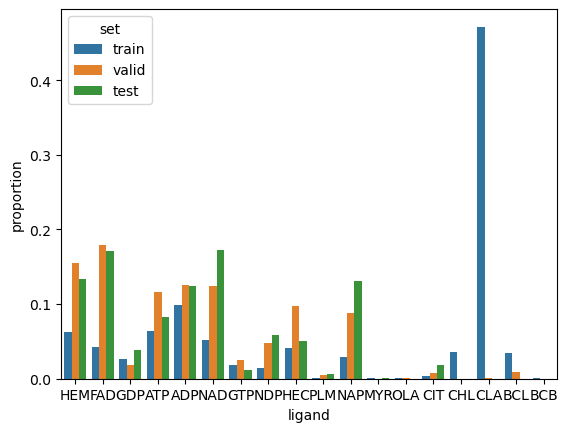

In [19]:
ligands_df = pd.DataFrame([], columns=['ligand', 'count', 'set'])
for split, ligands in {'train': train_ligands, 'valid': valid_ligands, 'test': test_ligands}.items():
    ligands = {k: v for k, v in ligands.items() if k in AF3_ligands}
    df = pd.DataFrame.from_dict(ligands, orient='index').reset_index()
    df.columns = ['ligand', 'count']
    df['set'] = split
    df['proportion'] = df['count'] / df['count'].sum()
    ligands_df = pd.concat([ligands_df, df])

sns.barplot(x='ligand', y='proportion', hue='set', data=ligands_df)

In [21]:
test_interface = get_interface_dataset(test, 'cofactor')
train_interface = get_interface_dataset(train, 'cofactor')
valid_interface = get_interface_dataset(valid, 'cofactor')

len(test_interface), len(train_interface), len(valid_interface)

(1260, 34925, 1579)

In [22]:
output_dir = "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/protein_interface/PL"
with open(f"{output_dir}/PL_sequence_30_test.pkl", 'wb') as f:
    pickle.dump(test_interface, f)
with open(f"{output_dir}/PL_sequence_30_train.pkl", 'wb') as f:
    pickle.dump(train_interface, f)
with open(f"{output_dir}/PL_sequence_30_valid.pkl", 'wb') as f:
    pickle.dump(valid_interface, f)

In [ ]:
output_dir = "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/protein_interface/PL"
for ligand in AF3_ligands:
    test_binary = get_binary_interface_dataset(test, ligand)
    train_binary = get_binary_interface_dataset(train, ligand)
    valid_binary = get_binary_interface_dataset(valid, ligand)

    with open(f"{output_dir}/PL_sequence_30_{ligand}_test.pkl", 'wb') as f:
        pickle.dump(test_binary, f)
    with open(f"{output_dir}/PL_sequence_30_{ligand}_train.pkl", 'wb') as f:
        pickle.dump(train_binary, f)
    with open(f"{output_dir}/PL_sequence_30_{ligand}_valid.pkl", 'wb') as f:
        pickle.dump(valid_binary, f)
    print(f"{ligand}: test={len(test_binary)} {sum([x['label'] for x in test_binary])/len(test_binary)}, train={len(train_binary)} {sum([x['label'] for x in train_binary])/len(train_binary)}, valid={len(valid_binary)} {sum([x['label'] for x in valid_binary])/len(valid_binary)}")

ADP: test=6654 0.023444544634806132, train=105090 0.0329717385098487, valid=7273 0.02722397910078372
ATP: test=6654 0.015779981965734897, train=105090 0.021277000666095728, valid=7273 0.02516155644163344
GTP: test=6654 0.0021039975954313195, train=105090 0.006327909410981064, valid=7273 0.005362298913790733
GDP: test=6654 0.007363991584009618, train=105090 0.008735369683128746, valid=7273 0.004124845318300564
FAD: test=6654 0.03231139164412383, train=105090 0.014206870301646208, valid=7273 0.03891104083596865
NAD: test=6654 0.03276224827171626, train=105090 0.017270910648015985, valid=7273 0.02708648425684037
NAP: test=6654 0.02479711451758341, train=105090 0.009658388048339519, valid=7273 0.018974288464182594
NDP: test=6654 0.010970844604749024, train=105090 0.004653154439052241, valid=7273 0.010449608139694762
HEM: test=6654 0.025247971145175834, train=105090 0.0209058901893615, valid=7273 0.03368623676612127
HEC: test=6654 0.009618274721971746, train=105090 0.01376915025216481, vali

cluster by 30% sequence similarity for positive and negative examples and split into train/test/val

In [8]:
dataset = test + train + valid
for ligand in AF3_ligands:
    output_dir = f"/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/protein_interface/PL/{ligand}"
    os.makedirs(output_dir, exist_ok=True)
    chosen_ligand_fastas, other_fastas = get_pl_fastas(dataset, ligand)
    print(f"{ligand}: {len(chosen_ligand_fastas)} {len(other_fastas)}")
    with open(f"{output_dir}/{ligand}.fasta", 'w') as f:
        for k, v in chosen_ligand_fastas.items():
            f.write(f">{k}\n{v}\n")
    with open(f"{output_dir}/not_{ligand}.fasta", 'w') as f:
        for k, v in other_fastas.items():
            f.write(f">{k}\n{v}\n")

ADP: 5295 172084
ATP: 4074 173305
GTP: 1102 176277
GDP: 1313 176066
FAD: 3062 174317
NAD: 3028 174351
NAP: 1656 175723
NDP: 757 176622
HEM: 3618 173761
HEC: 2356 175023
PLM: 71 177308
OLA: 14 177365
MYR: 44 177335
CIT: 207 177172
CLA: 25906 151473
CHL: 1824 175555
BCL: 3607 173772
BCB: 170 177209


In [ ]:
import random
random.seed(42)

def convert_item(item,label):
    return {
        'id': item['id'],
        'data': filter_for_segment(item['data'], 0),
        'label': label,
    }

for ligand in AF3_ligands:
    clusters_df = pd.read_csv(f"/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/protein_interface/PL/{ligand}/{ligand}_clusters_30_cluster.tsv", sep="\t", names=['cluster', 'id'])
    ligand_graph = nx.Graph()
    for row in clusters_df.itertuples():
        pdb_id = "_".join(row.id.split("_")[:-1])
        ligand_graph.add_edge(row.cluster, pdb_id)
    disconnected_ligand = list(nx.connected_components(ligand_graph))
    random.shuffle(disconnected_ligand)

    if len(disconnected_ligand) < 3:
        print(f"{ligand} has less than 3 clusters")
    num_test_clusters = min(1, int(len(disconnected_ligand)*0.1))

    train_clusters = disconnected_ligand[:-2*num_test_clusters]
    test_clusters = disconnected_ligand[-2*num_test_clusters:-num_test_clusters]
    valid_clusters = disconnected_ligand[-num_test_clusters:]
    train_ligand_ids = sum([list(x) for x in train_clusters], [])
    test_ligand_ids = sum([list(x) for x in test_clusters], [])
    valid_ligand_ids = sum([list(x) for x in valid_clusters], [])

    not_clusters_df = pd.read_csv(f"/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/protein_interface/PL/{ligand}/not_{ligand}_clusters_30_cluster.tsv", sep="\t", names=['cluster', 'id'])
    not_ligand_graph = nx.Graph()
    for row in not_clusters_df.itertuples():
        pdb_id = "_".join(row.id.split("_")[:-1])
        not_ligand_graph.add_edge(row.cluster, pdb_id)
    disconnected_not_ligand = list(nx.connected_components(not_ligand_graph))
    random.shuffle(disconnected_not_ligand)
    train_not_clusters = disconnected_not_ligand[:int(len(disconnected_not_ligand)*0.8)]
    test_not_clusters = disconnected_not_ligand[int(len(disconnected_not_ligand)*0.8):int(len(disconnected_not_ligand)*0.9)]
    valid_not_clusters = disconnected_not_ligand[int(len(disconnected_not_ligand)*0.9):]
    train_not_ligand_ids = sum([list(x) for x in train_not_clusters], [])
    test_not_ligand_ids = sum([list(x) for x in test_not_clusters], [])
    valid_not_ligand_ids = sum([list(x) for x in valid_not_clusters], [])

    train_ids = set([x for x in train_ligand_ids + train_not_ligand_ids if x.endswith(".pdb")])
    test_ids = set([x for x in test_ligand_ids + test_not_ligand_ids if x.endswith(".pdb")])
    valid_ids = set([x for x in valid_ligand_ids + valid_not_ligand_ids if x.endswith(".pdb")])

    train_ligand_dataset, test_ligand_dataset, valid_ligand_dataset = [], [], []
    for item in dataset:
        if item['id'] in train_ids:
            train_ligand_dataset.append(convert_item(item, item['id'].split("_")[-2]==ligand))
        elif item['id'] in test_ids:
            test_ligand_dataset.append(convert_item(item, item['id'].split("_")[-2]==ligand))
        elif item['id'] in valid_ids:
            valid_ligand_dataset.append(convert_item(item, item['id'].split("_")[-2]==ligand))
    
    output_dir = f"/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/protein_interface/PL/{ligand}"
    with open(f"{output_dir}/{ligand}_sequence_30_train.pkl", 'wb') as f:
        pickle.dump(train_ligand_dataset, f)
    with open(f"{output_dir}/{ligand}_sequence_30_test.pkl", 'wb') as f:
        pickle.dump(test_ligand_dataset, f)
    with open(f"{output_dir}/{ligand}_sequence_30_valid.pkl", 'wb') as f:
        pickle.dump(valid_ligand_dataset, f)

    print(ligand, sum([x['label'] for x in train_ligand_dataset])/len(train_ligand_dataset),  sum([x['label'] for x in valid_ligand_dataset])/len(valid_ligand_dataset),  sum([x['label'] for x in test_ligand_dataset])/len(test_ligand_dataset))

ADP 0.030863959606082216 0.04875239923224568 0.03165409482758621
ATP 0.01862277618399538 0.028383767300023458 0.04546542234984446
GTP 0.007015932681218231 0.004571677370197018 0.001173853947856172
GDP 0.0058288034579867705 0.008996663489037179 0.0293812976739806
FAD 0.014309796930708418 0.026375193061660925 0.03954496208017335
NAD 0.02547257670719122 0.0019325478461442553 0.019259061120770363
NAP 0.014045476976805983 0.0027892691488028082 0.014727722772277227
NDP 0.007572508245455756 0.002002147230362998 0.0033646183814414732
HEM 0.019304757382228383 0.028285573122529644 0.05029738815619343
HEC 0.019284215302592025 0.017612101566720693 0.003593455323920689
PLM 0.000418166011906727 0.00034301955211447053 0.0011632415664986429
OLA 9.75923956005348e-05 0.00012193634922570419 0.00011977482333213559
MYR 0.00026027589244599273 0.00018446781036709093 0.00012075836251660427
CIT 0.0014679226979142732 0.00034261508752258147 0.00175049597385926
CLA 0.0009066731141199226 0.57421095036256 0.0005161

In [ ]:
import random
random.seed(44)

def convert_item(item,label):
    return {
        'id': item['id'],
        'data': filter_for_segment(item['data'], 0),
        'label': label,
    }

for ligand in ['BCL', 'CHL', 'BCB', 'CLA']: # repeat for CLA only because its had a split where valid recieved all the CLA data 
    clusters_df = pd.read_csv(f"/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/protein_interface/PL/{ligand}/{ligand}_clusters_30_cluster.tsv", sep="\t", names=['cluster', 'id'])
    ligand_graph = nx.Graph()
    for row in clusters_df.itertuples():
        pdb_id = "_".join(row.id.split("_")[:-1])
        ligand_graph.add_edge(row.cluster, pdb_id)
    disconnected_ligand = list(nx.connected_components(ligand_graph))
    print(f"{ligand}: Ligand num clusters: ", len(disconnected_ligand))
    random.shuffle(disconnected_ligand)
    
    if len(disconnected_ligand) < 3:
        print(f"{ligand} has less than 3 clusters")
        continue
    num_test_clusters = max(1, int(len(disconnected_ligand)*0.1))

    train_clusters = disconnected_ligand[:-2*num_test_clusters]
    test_clusters = disconnected_ligand[-2*num_test_clusters:-num_test_clusters]
    valid_clusters = disconnected_ligand[-num_test_clusters:]
    train_ligand_ids = sum([list(x) for x in train_clusters], [])
    test_ligand_ids = sum([list(x) for x in test_clusters], [])
    valid_ligand_ids = sum([list(x) for x in valid_clusters], [])
    print(f"{ligand}: train={len(train_ligand_ids)}, test={len(test_ligand_ids)}, valid={len(valid_ligand_ids)}")

    not_clusters_df = pd.read_csv(f"/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/protein_interface/PL/{ligand}/not_{ligand}_clusters_30_cluster.tsv", sep="\t", names=['cluster', 'id'])
    not_ligand_graph = nx.Graph()
    for row in not_clusters_df.itertuples():
        pdb_id = "_".join(row.id.split("_")[:-1])
        not_ligand_graph.add_edge(row.cluster, pdb_id)
    disconnected_not_ligand = list(nx.connected_components(not_ligand_graph))
    print(f"{ligand}: Not ligand num clusters: ", len(disconnected_not_ligand))

    random.shuffle(disconnected_not_ligand)

    train_not_clusters = disconnected_not_ligand[:int(len(disconnected_not_ligand)*0.8)]
    test_not_clusters = disconnected_not_ligand[int(len(disconnected_not_ligand)*0.8):int(len(disconnected_not_ligand)*0.9)]
    valid_not_clusters = disconnected_not_ligand[int(len(disconnected_not_ligand)*0.9):]
    train_not_ligand_ids = sum([list(x) for x in train_not_clusters], [])
    test_not_ligand_ids = sum([list(x) for x in test_not_clusters], [])
    valid_not_ligand_ids = sum([list(x) for x in valid_not_clusters], [])

    train_ids = set([x for x in train_ligand_ids + train_not_ligand_ids if x.endswith(".pdb")])
    test_ids = set([x for x in test_ligand_ids + test_not_ligand_ids if x.endswith(".pdb")])
    valid_ids = set([x for x in valid_ligand_ids + valid_not_ligand_ids if x.endswith(".pdb")])

    train_ligand_dataset, test_ligand_dataset, valid_ligand_dataset = [], [], []
    for item in dataset:
        if item['id'] in train_ids:
            train_ligand_dataset.append(convert_item(item, item['id'].split("_")[-2]==ligand))
        elif item['id'] in test_ids:
            test_ligand_dataset.append(convert_item(item, item['id'].split("_")[-2]==ligand))
        elif item['id'] in valid_ids:
            valid_ligand_dataset.append(convert_item(item, item['id'].split("_")[-2]==ligand))
        
    output_dir = f"/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/protein_interface/PL/{ligand}"
    with open(f"{output_dir}/{ligand}_sequence_30_train.pkl", 'wb') as f:
        pickle.dump(train_ligand_dataset, f)
    with open(f"{output_dir}/{ligand}_sequence_30_test.pkl", 'wb') as f:
        pickle.dump(test_ligand_dataset, f)
    with open(f"{output_dir}/{ligand}_sequence_30_valid.pkl", 'wb') as f:
        pickle.dump(valid_ligand_dataset, f)
    
    print(ligand, sum([x['label'] for x in train_ligand_dataset])/len(train_ligand_dataset),  sum([x['label'] for x in valid_ligand_dataset])/len(valid_ligand_dataset),  sum([x['label'] for x in test_ligand_dataset])/len(test_ligand_dataset))

BCL: Ligand num clusters:  4
BCL: train cluster=[{'7c52_1.pdb_7c52_1_BCL_QE.pdb', '6z5s_1.pdb_6z5s_1_BCL_BD.pdb', '7vrj_1.pdb_7vrj_1_BCL_WD.pdb', '6z5s_1.pdb_6z5s_1_BCL_QA.pdb', '7voy_1.pdb_7voy_1_BCL_CB.pdb', '7xxf_1.pdb_7xxf_1_BCL_BD.pdb', '7xxf_1.pdb_7xxf_1_BCL_JE.pdb', '1kzu_1.pdb_1kzu_1_BCL_N1.pdb', '7vb9_1.pdb_7vb9_1_BCL_UC.pdb', '6z5r_1.pdb_6z5r_1_BCL_UD.pdb', '1ijd_1.pdb_1ijd_1_BCL_R.pdb', '7xxf_1.pdb_7xxf_1_BCL_WD.pdb', '7voy_1.pdb_7voy_1_BCL_KB.pdb', '8fb9_1.pdb_8fb9_1_BCL_RA.pdb', '5yq7_1.pdb_5yq7_1_BCL_OB.pdb', '1kzu_1.pdb_1kzu_1_BCL_H2.pdb', '7zcu_1.pdb_7zcu_1_BCL_DB.pdb', '6z5r_1.pdb_6z5r_1_BCL_RD.pdb', '7vy3_1.pdb_7vy3_1_BCL_AD.pdb', '7vrj_1.pdb_7vrj_1_BCL_FB.pdb', '8iun_1.pdb_8iun_1_BCL_VB.pdb', '8iug_1.pdb_8iug_1_BCL_CB.pdb', '7voy_1.pdb_7voy_1_BCL_FB.pdb', '6zxa_1.pdb_6zxa_1_BCL_VA.pdb', '1lgh_2.pdb_1lgh_2_BCL_PA3.pdb', '7c52_1.pdb_7c52_1_BCL_FD.pdb', '7f0l_1.pdb_7f0l_1_BCL_OD.pdb', '6z5r_1.pdb_6z5r_1_BCL_YB.pdb', '8iug_1.pdb_8iug_1_BCL_DB.pdb', '7ddq_1.pdb_7ddq_1_BCL

BCL: Not ligand num clusters:  8918
BCL 0.00903410519799586 0.03376224766851611 0.0019553072625698325
CHL: Ligand num clusters:  4
CHL: train cluster=[{'3pl9_1.pdb_3pl9_1_CHL_M.pdb', '3pl9_1.pdb_3pl9_1_CHL_E.pdb', '3pl9_1.pdb_3pl9_1_CHL_E.pdb_A', '3pl9_1.pdb_3pl9_1_CHL_G.pdb', '3pl9_1.pdb_3pl9_1_CHL_F.pdb'}, {'6gix_1.pdb_6gix_1_CHL_G.pdb', '6gix_1.pdb_6gix_1_CHL_H.pdb', '6gix_1.pdb_6gix_1_CHL_F.pdb', '6gix_1.pdb_6gix_1_CHL_E.pdb', '6gix_1.pdb_6gix_1_CHL_F.pdb_D'}], test cluster=[{'7dz7_1.pdb_7dz7_1_CHL_OO.pdb', '5xnm_1.pdb_5xnm_1_CHL_ZB.pdb', '6sl5_1.pdb_6sl5_1_CHL_XI.pdb', '7xqp_1.pdb_7xqp_1_CHL_EI.pdb', '7xqp_1.pdb_7xqp_1_CHL_BJ.pdb', '5xnl_1.pdb_5xnl_1_CHL_QD.pdb', '8c29_1.pdb_8c29_1_CHL_IH.pdb', '6zzy_1.pdb_6zzy_1_CHL_DM.pdb', '7yca_1.pdb_7yca_1_CHL_GR.pdb', '8hg5_1.pdb_8hg5_1_CHL_I.pdb', '3jcu_1.pdb_3jcu_1_CHL_SD.pdb', '6kac_1.pdb_6kac_1_CHL_BL.pdb', '5xnl_1.pdb_5xnl_1_CHL_UM.pdb', '6zzy_1.pdb_6zzy_1_CHL_BH.pdb', '7oui_1.pdb_7oui_1_CHL_QG.pdb', '7yca_1.pdb_7yca_1_CHL_FM.pdb', '7a4

In [26]:
for ligand in AF3_ligands:
    clusters_df = pd.read_csv(f"/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/protein_interface/PL/{ligand}/{ligand}_clusters_30_cluster.tsv", sep="\t", names=['cluster', 'id'])
    ligand_graph = nx.Graph()
    for row in clusters_df.itertuples():
        pdb_id = "_".join(row.id.split("_")[:-1])
        ligand_graph.add_edge(row.cluster, pdb_id)
    disconnected_ligand = list(nx.connected_components(ligand_graph))
    print(f"{ligand}: Ligand num clusters: ", len(disconnected_ligand))

ADP: Ligand num clusters:  522
ATP: Ligand num clusters:  421
GTP: Ligand num clusters:  111
GDP: Ligand num clusters:  165
FAD: Ligand num clusters:  285
NAD: Ligand num clusters:  211
NAP: Ligand num clusters:  184
NDP: Ligand num clusters:  118
HEM: Ligand num clusters:  229
HEC: Ligand num clusters:  107
PLM: Ligand num clusters:  28
OLA: Ligand num clusters:  6
MYR: Ligand num clusters:  9
CIT: Ligand num clusters:  51
CLA: Ligand num clusters:  9
CHL: Ligand num clusters:  4
BCL: Ligand num clusters:  4
BCB: Ligand num clusters:  1


remove those with ont enough ligands (less than 100) or not enough clusters (less than 10)
- not enough ligands: PLM, OLA, MYR
- not enough sequence difference in the binding pockets, so with 30% clustering they all end up in one cluster / one big cluster: BCL, CHL, BCB

remaining: ADP ATP GTP GDP FAD NAD NAP NDP HEM HEC CIT CLA

# Dark Proteome

In [7]:
import pickle
import torch

In [3]:
with open("/n/holystore01/LABS/mzitnik_lab/Lab/afang/protein_universe/foldseek_cluster/processed2/is_dark_90_plddt_PeSTo_80_ligand.pkl", "rb") as f:
    dark_proteome_ligand = pickle.load(f)
len(dark_proteome_ligand)

969

In [4]:
with open("/n/holystore01/LABS/mzitnik_lab/Lab/afang/protein_universe/foldseek_cluster/processed2/is_dark_90_plddt_PeSTo_80_ion.pkl", "rb") as f:
    dark_proteome_ion = pickle.load(f)
len(dark_proteome_ion)

2851

In [27]:
pion_model = torch.load("/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/multiclass_classifier/version_1/checkpoint/epoch26_step19710.ckpt")
batch_size = 16

predicted_ions = []
for i in range(0, len(dark_proteome_ion), batch_size):
    end = min(i+batch_size, len(dark_proteome_ion))
    batch = PDBDataset.collate_fn([dark_proteome_ion[j]['data'] for j in range(i, end)])
    batch = Trainer.to_device(batch, 'cuda')
    output = torch.argmax(pion_model.infer(batch), dim=1).detach().cpu()
    predicted_ions.extend([AF3_metal_ions[ion_idx] for ion_idx in output])
Counter(predicted_ions)

Counter({'ZN': 2139, 'MG': 712})

In [28]:
pl_model = torch.load("/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/models/multiclass_classifier/version_3/checkpoint/epoch21_step26840.ckpt")
batch_size = 16

predicted_ligands = []
for i in range(0, len(dark_proteome_ligand), batch_size):
    end = min(i+batch_size, len(dark_proteome_ligand))
    batch = PDBDataset.collate_fn([dark_proteome_ligand[j]['data'] for j in range(i, end)])
    batch = Trainer.to_device(batch, 'cuda')
    output = torch.argmax(pl_model.infer(batch), dim=1).detach().cpu()
    predicted_ligands.extend([AF3_ligands[ligand_idx] for ligand_idx in output])
Counter(predicted_ligands)

Counter({'NAD': 334, 'HEM': 191, 'ATP': 188, 'CLA': 160, 'ADP': 96})

In [29]:
len(predicted_ligands), len(dark_proteome_ligand)

(969, 969)

In [31]:
# for any missing fastas rewrite them
from Bio import PDB
from Bio.SeqUtils import seq1
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio import SeqIO
from Bio.SeqIO.FastaIO import FastaWriter

def pdb_to_fasta(pdb_filename):
    structure_id = os.path.basename(pdb_filename).split('.')[0]

    # Create a PDB parser
    parser = PDB.PDBParser(QUIET=True)

    # Parse the structure
    structure = parser.get_structure("protein_structure", pdb_filename)

    output = {}

    # Open the FASTA file for writing
    for model in structure:
        for chain in model:
            sequence = ""
            for residue in chain:
                # Ensure the residue is an amino acid
                if PDB.is_aa(residue, standard=True):
                    sequence += seq1(residue.get_resname())
            
            # Create a sequence record for the chain
            seq_record = SeqRecord(
                Seq(sequence),
                id=f"{structure_id}_{chain.id}",
                description=f"Chain {chain.id}"
            )

            output[seq_record.id] = str(seq_record.seq)
    return output

fastas = []
for item in dark_proteome_ligand:
    x = item['id']
    fastas.append(pdb_to_fasta(f"/n/holystore01/LABS/mzitnik_lab/Lab/afang/protein_universe/foldseek_cluster/is_dark_90_plddt/AF-{x}-F1-model_v4.pdb")[f'AF-{x}-F1-model_v4_A'])

In [33]:
import random
random.seed(42)

random_ligands = []
for predicted_ligand in predicted_ligands:
    random_ligands.append(random.sample([x for x in AF3_ligands if x != predicted_ligand], 1)[0])

In [36]:
import json 

out_dir = "/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/Pligand_MLP/"
os.makedirs(f"{out_dir}/outputs/model", exist_ok=True)
os.makedirs(f"{out_dir}/outputs/reference", exist_ok=True)

chunk_size = len(dark_proteome_ligand)//5
chunks = range(0, len(dark_proteome_ligand)+chunk_size, chunk_size)
chunks = list(zip(chunks[:-1], chunks[1:]))
chunks[-1] = (chunks[-1][0], len(dark_proteome_ligand))

# write AF3 format
jobs = []
for chunk_i, (start, end) in enumerate(chunks):
    os.makedirs(f"{out_dir}/inputs/model{chunk_i}", exist_ok=True)
    os.makedirs(f"{out_dir}/inputs/reference{chunk_i}", exist_ok=True)
    for i in range(start, end):
        item_job1 = {
            "name": dark_proteome_ligand[i]["id"] + '_model',
            "modelSeeds": [1],
            "sequences": [
                {"protein": {"id": 'A', "sequence": fastas[i]}},
                {"ligand": {"id": ['B'], "ccdCodes": [predicted_ligands[i]]}},
            ],
            "dialect": "alphafold3",
            "version": 1
        }

        item_job2 = {
            "name": dark_proteome_ligand[i]["id"] + '_reference',
            "modelSeeds": [1],
            "sequences": [
                {"protein": {"id": 'A', "sequence": fastas[i]}},
                {"ligand": {"id": ['B'], "ccdCodes": [random_ligands[i]]}},
            ],
            "dialect": "alphafold3",
            "version": 1
        }
        with open(f'{out_dir}/inputs/model{chunk_i}/{dark_proteome_ligand[i]["id"]}_model.json', 'w') as f:
            json.dump(item_job1, f, indent=2)
        with open(f'{out_dir}/inputs/reference{chunk_i}/{dark_proteome_ligand[i]["id"]}_reference.json', 'w') as f:
            json.dump(item_job2, f, indent=2)

In [10]:
# AF3 has issues with HEC ligand, 
#   File "/n/netscratch/mzitnik_lab/Lab/afang/af3_env/lib/python3.11/site-packages/alphafold3/model/features.py", line 1551, in get_reference
#  if max_modified_date < ref_max_modified_date:
# TypeError: '<' not supported between instances of 'datetime.date' and 'NoneType'
# so we use the SMILES representation of HEC
import json 
out_dir = "/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/Pligand_MLP/"

for chunk_i in range(5):
    for item in os.listdir(f'{out_dir}/inputs/model{chunk_i}'):
        with open(f'{out_dir}/inputs/model{chunk_i}/{item}', 'r') as f:
            job = json.load(f)
        
        if 'smiles' in job['sequences'][1]['ligand']:
            print(f'{out_dir}/inputs/model{chunk_i}/{item} already rewritten')
            continue
        if job['sequences'][1]['ligand']['ccdCodes'][0] == 'HEC':
            job['sequences'][1]['ligand'] = {
                "id": 'B',
                "smiles": "CC=C1C(=C2C=C3C(=CC)C(=C4N3[Fe]56N2C1=Cc7n5c(c(c7C)CCC(=O)O)C=C8N6C(=C4)C(=C8CCC(=O)O)C)C)C",
            }
        
            with open(f'{out_dir}/inputs/model{chunk_i}/{item}', 'w') as f:
                json.dump(job, f, indent=2)
            
            print(f'{out_dir}/inputs/model{chunk_i}/{item} rewritten')
    
    for item in os.listdir(f'{out_dir}/inputs/reference{chunk_i}'):
        with open(f'{out_dir}/inputs/reference{chunk_i}/{item}', 'r') as f:
            job = json.load(f)
        
        if 'smiles' in job['sequences'][1]['ligand']:
            print(f'{out_dir}/inputs/reference{chunk_i}/{item} already rewritten')
            continue
        if job['sequences'][1]['ligand']['ccdCodes'][0] == 'HEC':
            job['sequences'][1]['ligand'] = {
                "id": 'B',
                "smiles": "CC=C1C(=C2C=C3C(=CC)C(=C4N3[Fe]56N2C1=Cc7n5c(c(c7C)CCC(=O)O)C=C8N6C(=C4)C(=C8CCC(=O)O)C)C)C",
            }
        
            with open(f'{out_dir}/inputs/reference{chunk_i}/{item}', 'w') as f:
                json.dump(job, f, indent=2)
        
            print(f'{out_dir}/inputs/reference{chunk_i}/{item} rewritten')

/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/Pligand_MLP//inputs/reference0/A0A0G1EXR8_reference.json already rewritten
/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/Pligand_MLP//inputs/reference0/A0A143XC97_reference.json already rewritten
/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/Pligand_MLP//inputs/reference0/A0A1F9ETZ8_reference.json already rewritten
/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/Pligand_MLP//inputs/reference0/A0A285PTF6_reference.json already rewritten
/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/Pligand_MLP//inputs/reference0/A0A2D6A351_reference.json already rewritten
/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/Pligand_MLP//inputs/reference0/A0A399WB00_reference.json already rewritten
/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/Pligand_MLP//inputs/reference0/A0A3D4K4D3_reference.json already rewritten
/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/Pligand_MLP//inputs/reference0/A0A521L3Z4_reference.json already rewritten
/n/netscratch/mzitnik_la

## Analyse AF3 output

In [1]:
# analyse AF3 output
from glob import glob
import json
import os
import numpy as np
model_outputs = glob("/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/PL_cosine_k10_fisher/outputs/model/**/*summary_confidences.json")
reference_outputs = glob("/n/netscratch/mzitnik_lab/Lab/afang/AF3-output/Pligand_MLP/outputs/reference/**/*_summary_confidences.json")

iptm_results = {}
ptm_results = {}
ligands = {}
for fname in model_outputs:
    with open(fname, 'r') as f:
        data = json.load(f)
    id_name = os.path.basename(fname).replace("_summary_confidences.json", "")
    iptm_results[id_name] = data['iptm']
    ptm_results[id_name] = data['ptm']
    with open(fname.replace("_summary_confidences.json", "_data.json"), 'r') as f:
        data = json.load(f)
    if 'ccdCodes' in data['sequences'][1]['ligand']:
        ligand = data['sequences'][1]['ligand']['ccdCodes'][0]
    else:
        ligand = data['sequences'][1]['ligand']['smiles']
        if ligand == 'CC=C1C(=C2C=C3C(=CC)C(=C4N3[Fe]56N2C1=Cc7n5c(c(c7C)CCC(=O)O)C=C8N6C(=C4)C(=C8CCC(=O)O)C)C)C':
            ligand = 'HEC'
    ligands[id_name] = ligand
for fname in reference_outputs:
    with open(fname, 'r') as f:
        data = json.load(f)
    id_name = os.path.basename(fname).replace("_summary_confidences.json", "")
    iptm_results[id_name] = data['iptm']
    ptm_results[id_name] = data['ptm']
    with open(fname.replace("_summary_confidences.json", "_data.json"), 'r') as f:
        data = json.load(f)
    if 'ccdCodes' in data['sequences'][1]['ligand']:
        ligand = data['sequences'][1]['ligand']['ccdCodes'][0]
    else:
        ligand = data['sequences'][1]['ligand']['smiles']
        if ligand == 'CC=C1C(=C2C=C3C(=CC)C(=C4N3[Fe]56N2C1=Cc7n5c(c(c7C)CCC(=O)O)C=C8N6C(=C4)C(=C8CCC(=O)O)C)C)C':
            ligand = 'HEC'
    ligands[id_name] = ligand

completed_ids = set([k.split("_")[0] for k in iptm_results.keys()])
model_iptms, model_ptms = [], []
reference_iptms, reference_ptms = [], []
ids = []
for id_name in completed_ids:
    model_id = id_name + "_model"
    reference_id = id_name + "_reference"
    if model_id not in iptm_results or reference_id not in iptm_results:
        continue
    
    ids.append(id_name)
    model_iptms.append(iptm_results[model_id])
    model_ptms.append(ptm_results[model_id])
    reference_iptms.append(iptm_results[reference_id])
    reference_ptms.append(ptm_results[reference_id])

model_iptms = np.array(model_iptms)
model_ptms = np.array(model_ptms)
reference_iptms = np.array(reference_iptms)
reference_ptms = np.array(reference_ptms)

In [4]:
iptm_df = []
for key in ligands.keys():
    if key.split("_")[0] not in completed_ids:
        continue
    iptm_df.append({
        "id": key.split("_")[0],
        "type": key.split("_")[1],
        "ligand": ligands[key],
        "iptm": iptm_results[key],
    })
iptm_df = pd.DataFrame(iptm_df)
iptm_df[iptm_df.id.isin(ids)].groupby(['ligand','type'])[["iptm"]].agg(['count', 'mean', 'std'])

iptm                    
                 count      mean       std
ligand type                               
ADP    model        34  0.805000  0.113144
       reference    33  0.780000  0.104133
ATP    model       147  0.763741  0.115273
       reference    31  0.783871  0.117917
BCB    reference    29  0.634138  0.111756
BCL    model        10  0.704000  0.121582
       reference    44  0.635909  0.163896
CHL    model         7  0.734286  0.126736
       reference    56  0.631250  0.150116
CIT    model       243  0.849177  0.099719
       reference    47  0.845319  0.113786
CLA    model       125  0.596240  0.148197
       reference    41  0.615366  0.154128
FAD    model         3  0.686667  0.096090
       reference    41  0.724634  0.113624
GDP    model        23  0.762174  0.108291
       reference    56  0.769821  0.112014
GTP    model        84  0.741310  0.134333
       reference    43  0.781860  0.108106
HEC    reference    55  0.715455  0.102520
HEM    model         4  0.620000  0.137356
       reference    46  0.688261  0.141834
MYR    model        30  0.790333  0.102031
       reference    38  0.803421  0.099872
NAD    model         6  0.605000  0.130652
       reference    22  0.693636  0.132469
NAP    model         9  0.680000  0.087607
       reference    48  0.686250  0.149618
NDP    model         3  0.693333  0.100167
       reference    44  0.666591  0.153167
OLA    model         2  0.805000  0.021213
       reference    39  0.779487  0.133947
PLM    model        33  0.796667  0.094659
       reference    50  0.806400  0.091802

Model: mean iPTM=0.760786369593709, mean PTM=0.7906159895150721
Reference: mean iPTM=0.7247051114023592, mean PTM=0.7791480996068152
Num samples: 763


/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/n/home13/afang/.conda/envs/in

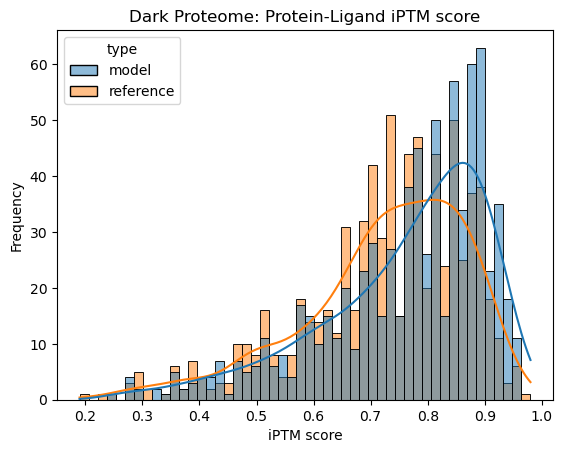

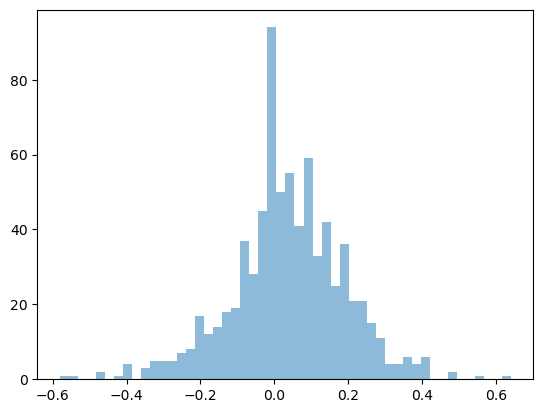

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print(f"Model: mean iPTM={np.mean(model_iptms)}, mean PTM={np.mean(model_ptms)}")
print(f"Reference: mean iPTM={np.mean(reference_iptms)}, mean PTM={np.mean(reference_ptms)}")
print(f"Num samples: {len(model_iptms)}")

sns.histplot(data=iptm_df[iptm_df.id.isin(ids)], x='iptm', hue='type', bins=50, kde=True)
plt.xlabel("iPTM score")
plt.ylabel("Frequency")
plt.title("Dark Proteome: Protein-Ligand iPTM score")
plt.show()

plt.hist(model_iptms-reference_iptms, bins=50, alpha=0.5, label='model-reference')
plt.show()

/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/n/home13/afang/.conda/envs/in

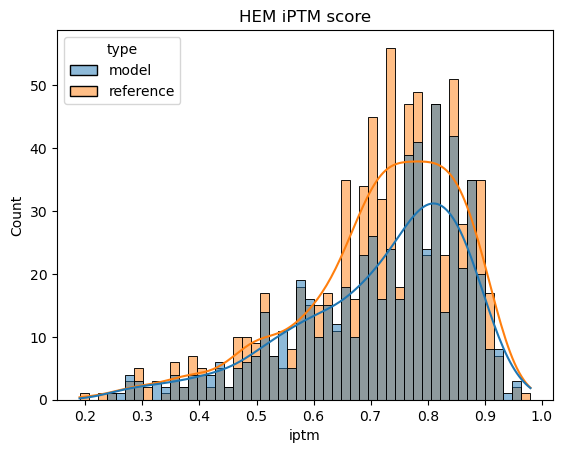

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(data=iptm_df[iptm_df.ligand != 'CIT'], x='iptm', hue='type', bins=50, kde=True)
plt.title("HEM iPTM score")
plt.show()